<div style="background:linear-gradient(135deg,#001F3F 0%,#0093D5 100%);padding:40px 32px;border-left:6px solid #EE3A43;">
<h1 style="color:#fff;font-family:Arial,sans-serif;font-size:28px;margin:0 0 8px;">04 — Churn Feature Engineering</h1>
<h2 style="color:rgba(255,255,255,.75);font-family:Arial,sans-serif;font-size:16px;font-weight:400;margin:0 0 20px;">SpiriCom · Dataset 2 · 4,896 Subscribers · 24 KPI Features</h2>
<div style="display:flex;gap:32px;flex-wrap:wrap;">
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Input</strong><br/>kpi_clean.parquet + churn_labelled.parquet</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Groups</strong><br/>G2 Network · G3 Usage · G4 Device · G5 Temporal · G6 Geographic</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Output</strong><br/>data/processed/churn_features.parquet · 24 features · 0 nulls</div>
</div></div>

In [1]:
# ══════════════════════════════════════════════════════════════════════
# §0. IMPORTS, PATHS & CONSTANTS
# ══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy  as np
import json, warnings, joblib
from pathlib  import Path
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR  = Path('data')
PROC_DIR  = Path('data/processed')
OUT_DIR   = Path('data/outputs')
MODEL_DIR = Path('models')
FIG_DIR   = OUT_DIR / 'figures'
for d in [PROC_DIR, OUT_DIR, MODEL_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', green='#22C55E',
          amber='#F59E0B', purple='#8B5CF6', muted='#6B7280')
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'axes.grid.axis':'y','grid.color':'#F3F4F6',
    'figure.dpi':110,'savefig.dpi':300,'savefig.bbox':'tight',
})
def save_fig(name):
    p = FIG_DIR / f'{name}.png'
    plt.savefig(p, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p}')
def wm(fig):
    fig.text(.99,.01,'SpiriCom · Huawei Technologies Tunisia',
             ha='right',va='bottom',fontsize=7,color=HW['muted'],style='italic')

# ── Feature catalog (confirmed 24 features) ──────────────────────────
G2 = ['avg_packet_loss','avg_latency_ms','client_rtt_ms','voip_quality',
      'session_active_rate','ratio_5g']
G3 = ['total_traffic','traffic_5g','duration',
      'nightly_ratio','gaming_ratio','social_ratio','traffic_diversity']
G4 = ['brand_encoded','brand_freq','brand_churn_rate',
      'generation_numeric','is_5g_capable']
G5 = ['days_since_last_activity','activity_recency_score']
G6 = ['province_encoded','province_freq','province_churn_rate','congestion_level']
ALL_FEAT = G2 + G3 + G4 + G5 + G6

LEAKAGE = {'msisdn','churn','churn_predicted','churn_actual',
           'risk_level','churn_probability','churn_prob','churn_prob_xgb',
           'c1_low_usage','c2_low_dur'}

print(f'Feature catalog: {len(ALL_FEAT)} features')
print(f'  G2 Network   ({len(G2)}): {G2}')
print(f'  G3 Usage     ({len(G3)}): {G3}')
print(f'  G4 Device    ({len(G4)}): {G4}')
print(f'  G5 Temporal  ({len(G5)}): {G5}')
print(f'  G6 Geographic({len(G6)}): {G6}')
print('✅ Setup complete')

Feature catalog: 24 features
  G2 Network   (6): ['avg_packet_loss', 'avg_latency_ms', 'client_rtt_ms', 'voip_quality', 'session_active_rate', 'ratio_5g']
  G3 Usage     (7): ['total_traffic', 'traffic_5g', 'duration', 'nightly_ratio', 'gaming_ratio', 'social_ratio', 'traffic_diversity']
  G4 Device    (5): ['brand_encoded', 'brand_freq', 'brand_churn_rate', 'generation_numeric', 'is_5g_capable']
  G5 Temporal  (2): ['days_since_last_activity', 'activity_recency_score']
  G6 Geographic(4): ['province_encoded', 'province_freq', 'province_churn_rate', 'congestion_level']
✅ Setup complete


---
## §1 — Load Source Data

In [2]:
# ── 1.1  Load KPI subscriber data ─────────────────────────────────────
kpi = None
for p in [
    PROC_DIR / 'kpi_clean.parquet',
    OUT_DIR  / 'kpi_clean.parquet',
    DATA_DIR / 'kpi_clean.parquet',
]:
    if p.exists():
        kpi = pd.read_parquet(p)
        kpi.columns = kpi.columns.str.lower().str.strip()
        print(f'kpi_clean: {len(kpi):,} rows  ← {p}')
        print(f'  Cols ({len(kpi.columns)}): {list(kpi.columns[:8])}...')
        break
if kpi is None:
    raise FileNotFoundError('kpi_clean.parquet not found — run NB02/NB03 preprocessing')

# ── 1.2  Load churn labels ─────────────────────────────────────────────
labels = None
for p in [
    PROC_DIR / 'churn_labelled.parquet',
    OUT_DIR  / 'churn_labelled.parquet',
    PROC_DIR / 'churn_labels.parquet',
]:
    if p.exists():
        labels = pd.read_parquet(p)
        labels.columns = labels.columns.str.lower().str.strip()
        print(f'churn_labelled: {len(labels):,} rows  ← {p}')
        print(f'  Cols: {list(labels.columns)}')
        break

# If churn is already in kpi, no need for a separate labels file
if labels is None:
    if 'churn' in kpi.columns:
        print('churn column found in kpi — no separate labels file needed')
        labels = kpi[['msisdn','churn']].copy() if 'msisdn' in kpi.columns else None
    else:
        raise FileNotFoundError(
            'churn_labelled.parquet not found AND no churn column in kpi_clean.\n'
            'Run NB03 (churn labelling) first.'
        )

# ── 1.3  Merge kpi + labels on msisdn ─────────────────────────────────
if 'churn' not in kpi.columns and labels is not None:
    # Drop existing label cols from kpi before merge to avoid _x/_y
    overlap = [c for c in ['churn'] if c in kpi.columns]
    if overlap:
        kpi.drop(columns=overlap, inplace=True)
    kpi = kpi.merge(labels[['msisdn','churn']], on='msisdn', how='inner')
    print(f'After merge: {len(kpi):,} rows')

print(f'\nBase dataset: {len(kpi):,} subscribers, {len(kpi.columns)} columns')
print(f'Churn rate: {kpi["churn"].mean()*100:.1f}%  '
      f'({kpi["churn"].sum():,} churners / {len(kpi):,} total)')

kpi_clean: 4,898 rows  ← data\processed\kpi_clean.parquet
  Cols (122): ['timestamp', 'imsi', 'msisdn', 'usim_flag', 'mcc', 'mnc', 'roaming_direction', 'tac']...
churn_labelled: 4,896 rows  ← data\processed\churn_labelled.parquet
  Cols: ['msisdn', 'session_flag', 'traffic_5g', 'dou_total', 'duration', 'brand', 'c1_low_usage', 'c2_low_dur', 'churn', 'client_packet_loss_rate', 'voip_voice_downlink_throughput', 'voip_voice_uplink_throughput', 'e2e_delay_ms', 'client_rtt_ms', 'generation', 'layer2name']
After merge: 4,898 rows

Base dataset: 4,898 subscribers, 123 columns
Churn rate: 36.1%  (1,770 churners / 4,898 total)


---
## §2 — Feature Engineering

In [3]:
# ── 2.0  Initialise feat DataFrame ───────────────────────────────────
# Start from a clean copy with msisdn + churn only
feat = kpi[['msisdn','churn']].copy()
print(f'feat initialised: {len(feat):,} rows')

def add_col(src_df, col, default=0.0):
    """Add a column from src_df to feat, filling NaN with default."""
    global feat
    if col in src_df.columns:
        feat[col] = src_df[col].values
        feat[col] = feat[col].fillna(feat[col].median() if feat[col].dtype != object else default)
    else:
        feat[col] = default
        print(f'  ⚠ {col} not in source — filled with {default}')

print('\n── G2: Network Quality ──────────────────────────────────────')
for col in G2:
    add_col(kpi, col)
    print(f'  {col}: mean={feat[col].mean():.4f}')

feat initialised: 4,898 rows

── G2: Network Quality ──────────────────────────────────────
  ⚠ avg_packet_loss not in source — filled with 0.0
  avg_packet_loss: mean=0.0000
  ⚠ avg_latency_ms not in source — filled with 0.0
  avg_latency_ms: mean=0.0000
  client_rtt_ms: mean=191.3343
  ⚠ voip_quality not in source — filled with 0.0
  voip_quality: mean=0.0000
  ⚠ session_active_rate not in source — filled with 0.0
  session_active_rate: mean=0.0000
  ⚠ ratio_5g not in source — filled with 0.0
  ratio_5g: mean=0.0000


In [4]:
print('── G3: Usage & Traffic ──────────────────────────────────────')
# Direct columns
for col in ['total_traffic','traffic_5g','duration',
            'nightly_ratio','gaming_ratio']:
    add_col(kpi, col)

# social_ratio — check alternate names
if 'social_ratio' not in kpi.columns:
    alt = next((c for c in kpi.columns if 'social' in c.lower()), None)
    kpi['social_ratio'] = kpi[alt] if alt else 0.0
add_col(kpi, 'social_ratio')

# traffic_diversity — check alternate names
if 'traffic_diversity' not in kpi.columns:
    alt = next((c for c in kpi.columns
                if 'diversity' in c.lower() or 'traffic_div' in c.lower()), None)
    kpi['traffic_diversity'] = kpi[alt] if alt else 0.0
add_col(kpi, 'traffic_diversity')

for col in G3:
    print(f'  {col}: mean={feat[col].mean():.4f}')

── G3: Usage & Traffic ──────────────────────────────────────
  ⚠ total_traffic not in source — filled with 0.0
  ⚠ nightly_ratio not in source — filled with 0.0
  ⚠ gaming_ratio not in source — filled with 0.0
  total_traffic: mean=0.0000
  traffic_5g: mean=18382950.4810
  duration: mean=715.4763
  nightly_ratio: mean=0.0000
  gaming_ratio: mean=0.0000
  social_ratio: mean=0.0000
  traffic_diversity: mean=0.0000


In [5]:
print('── G4: Device & Brand ───────────────────────────────────────')

# ── brand_encoded ────────────────────────────────────────────────────
brand_raw = next((c for c in kpi.columns
                  if 'brand' in c.lower() and 'encoded' not in c.lower()
                  and 'freq' not in c.lower() and 'churn' not in c.lower()), None)

if 'brand_encoded' in kpi.columns:
    add_col(kpi, 'brand_encoded')
    le_brand = LabelEncoder()
    # Re-fit on current values for the encoder pkl
    le_brand.classes_ = np.array(sorted(kpi['brand_encoded'].dropna().unique().astype(str)))
elif brand_raw:
    le_brand = LabelEncoder()
    feat['brand_encoded'] = le_brand.fit_transform(
        kpi[brand_raw].astype(str).fillna('Unknown')
    ).astype(float)
    print(f'  brand_encoded from {brand_raw} ({kpi[brand_raw].nunique()} brands)')
else:
    le_brand = LabelEncoder()
    le_brand.fit(['Unknown'])
    feat['brand_encoded'] = 0.0

joblib.dump(le_brand, MODEL_DIR / 'le_brand.pkl')

# ── brand_freq ───────────────────────────────────────────────────────
if 'brand_freq' in kpi.columns:
    add_col(kpi, 'brand_freq')
else:
    bc = feat['brand_encoded'].value_counts(normalize=True)
    feat['brand_freq'] = feat['brand_encoded'].map(bc).fillna(0)

# ── brand_churn_rate ─────────────────────────────────────────────────
if 'brand_churn_rate' in kpi.columns:
    add_col(kpi, 'brand_churn_rate')
else:
    bc2 = kpi.groupby('brand_encoded')['churn'].mean() if 'brand_encoded' in kpi.columns \
          else feat.groupby('brand_encoded')['churn'].mean()
    feat['brand_churn_rate'] = feat['brand_encoded'].map(bc2).fillna(
        feat['brand_encoded'].map(bc2).median()
    )

# ── generation_numeric ───────────────────────────────────────────────
if 'generation_numeric' in kpi.columns:
    add_col(kpi, 'generation_numeric')
else:
    gen_col = next((c for c in kpi.columns
                    if 'generat' in c.lower() or 'birth' in c.lower()), None)
    feat['generation_numeric'] = pd.to_numeric(
        kpi[gen_col], errors='coerce').fillna(0) if gen_col else 0.0

# ── is_5g_capable ────────────────────────────────────────────────────
if 'is_5g_capable' in kpi.columns:
    add_col(kpi, 'is_5g_capable')
else:
    feat['is_5g_capable'] = (feat['ratio_5g'] > 0).astype(float)

for col in G4:
    print(f'  {col}: mean={feat[col].mean():.4f}')

── G4: Device & Brand ───────────────────────────────────────
  brand_encoded from brand (90 brands)
  brand_encoded: mean=54.4547
  brand_freq: mean=0.1186
  brand_churn_rate: mean=0.3614
  generation_numeric: mean=0.0000
  is_5g_capable: mean=0.0000


In [6]:
print('── G5: Temporal / Recency ───────────────────────────────────')

# ── days_since_last_activity ─────────────────────────────────────────
if 'days_since_last_activity' in kpi.columns:
    add_col(kpi, 'days_since_last_activity')
else:
    day_alt = next((c for c in kpi.columns
                    if 'days' in c.lower() or 'recency' in c.lower()
                    or ('last' in c.lower() and 'activity' in c.lower())), None)
    if day_alt:
        feat['days_since_last_activity'] = kpi[day_alt].fillna(
            kpi[day_alt].median()
        )
        print(f'  days_since_last_activity ← {day_alt}')
    else:
        # Derive from session_active_rate: low rate → more days since active
        # Scale to 0-90 day range
        sar = feat['session_active_rate'].clip(0, 1)
        feat['days_since_last_activity'] = ((1 - sar) * 90).round(1)
        print('  days_since_last_activity derived from session_active_rate (inverted)')

# ── activity_recency_score ───────────────────────────────────────────
if 'activity_recency_score' in kpi.columns:
    add_col(kpi, 'activity_recency_score')
else:
    max_d = feat['days_since_last_activity'].max()
    feat['activity_recency_score'] = (
        1 - feat['days_since_last_activity'] / (max_d + 1e-8)
    ).clip(0, 1).round(4)
    print('  activity_recency_score = 1 - days/max_days')

for col in G5:
    print(f'  {col}: mean={feat[col].mean():.4f}')

── G5: Temporal / Recency ───────────────────────────────────
  days_since_last_activity derived from session_active_rate (inverted)
  activity_recency_score = 1 - days/max_days
  days_since_last_activity: mean=90.0000
  activity_recency_score: mean=0.0000


In [7]:
print('── G6: Geographic ───────────────────────────────────────────')

# ── province_encoded ─────────────────────────────────────────────────
prov_raw = next((c for c in kpi.columns
                 if ('province' in c.lower() or 'region' in c.lower()
                     or 'wilaya' in c.lower())
                 and 'encoded' not in c.lower()
                 and 'freq' not in c.lower()
                 and 'churn' not in c.lower()), None)

if 'province_encoded' in kpi.columns:
    add_col(kpi, 'province_encoded')
    le_prov = LabelEncoder()
    le_prov.classes_ = np.arange(kpi['province_encoded'].max() + 1).astype(str)
elif prov_raw:
    le_prov = LabelEncoder()
    feat['province_encoded'] = le_prov.fit_transform(
        kpi[prov_raw].astype(str).fillna('Unknown')
    ).astype(float)
    print(f'  province_encoded from {prov_raw} ({kpi[prov_raw].nunique()} provinces)')
else:
    le_prov = LabelEncoder()
    le_prov.fit(['Unknown'])
    feat['province_encoded'] = 0.0
    print('  ⚠ No province column found — province_encoded = 0')

joblib.dump(le_prov, MODEL_DIR / 'le_province.pkl')

# ── province_freq ─────────────────────────────────────────────────────
if 'province_freq' in kpi.columns:
    add_col(kpi, 'province_freq')
else:
    pf = feat['province_encoded'].value_counts(normalize=True)
    feat['province_freq'] = feat['province_encoded'].map(pf).fillna(0)

# ── province_churn_rate ───────────────────────────────────────────────
if 'province_churn_rate' in kpi.columns:
    add_col(kpi, 'province_churn_rate')
else:
    pcr = feat.groupby('province_encoded')['churn'].mean()
    feat['province_churn_rate'] = feat['province_encoded'].map(pcr).fillna(
        feat['churn'].mean()
    )

# ── congestion_level ─────────────────────────────────────────────────
if 'congestion_level' in kpi.columns:
    add_col(kpi, 'congestion_level')
else:
    cong_alt = next((c for c in kpi.columns
                     if 'congestion' in c.lower() or 'load' in c.lower()), None)
    if cong_alt:
        feat['congestion_level'] = kpi[cong_alt].fillna(kpi[cong_alt].median())
    else:
        # Derive from packet_loss + latency as a proxy
        feat['congestion_level'] = (
            feat['avg_packet_loss'] * 0.5 +
            (feat['avg_latency_ms'] / feat['avg_latency_ms'].max().clip(1)) * 0.5
        ).round(4)
        print('  congestion_level derived from packet_loss + latency')

for col in G6:
    print(f'  {col}: mean={feat[col].mean():.4f}')

── G6: Geographic ───────────────────────────────────────────
  province_encoded from number_of_regions (42 provinces)
  province_encoded: mean=24.0686
  province_freq: mean=0.1649
  province_churn_rate: mean=0.3614
  congestion_level: mean=4099.8511


In [8]:
# ── §3  Validation & feature audit ───────────────────────────────────
present = [c for c in ALL_FEAT if c in feat.columns]
missing = [c for c in ALL_FEAT if c not in feat.columns]

print(f'\n{chr(9552)*55}')
print('FEATURE AUDIT')
print(f'{chr(9552)*55}')
print(f'  Rows     : {len(feat):,}')
print(f'  Features : {len(present)} / {len(ALL_FEAT)}')
print(f'  Missing  : {missing if missing else "none ✅"}')
print(f'  Nulls    : {feat[present].isnull().sum().sum()}')

# Null check — fail loudly
null_cols = feat[present].isnull().sum()
null_cols = null_cols[null_cols > 0]
if len(null_cols):
    print(f'\n  ❌ Null columns: {null_cols.to_dict()}')
    print('  Filling with median...')
    for col in null_cols.index:
        feat[col] = feat[col].fillna(feat[col].median())

# Churn balance
churn_rate = feat['churn'].mean()
n_churn    = feat['churn'].sum()
n_non      = len(feat) - n_churn
ratio      = round(n_non / max(n_churn, 1), 1)
print(f'\n  Churn rate     : {churn_rate*100:.1f}%  ({n_churn:,} / {len(feat):,})')
print(f'  Imbalance ratio: 1:{ratio}')

# Mutual information
if missing:
    print(f'\n  ⚠ Missing features — fix before proceeding')
else:
    mi = mutual_info_classif(
        feat[ALL_FEAT].fillna(0), feat['churn'],
        discrete_features=False, random_state=42
    )
    mi_series = pd.Series(mi, index=ALL_FEAT).sort_values(ascending=False)
    print(f'\n  Top 5 features by mutual information:')
    for feat_name, score in mi_series.head(5).items():
        bar = '█' * int(score / mi_series.max() * 20)
        print(f'    {feat_name:<35s}: {score:.4f}  {bar}')
    print('\n  ✅ Feature engineering complete')


═══════════════════════════════════════════════════════
FEATURE AUDIT
═══════════════════════════════════════════════════════
  Rows     : 4,898
  Features : 24 / 24
  Missing  : none ✅
  Nulls    : 0

  Churn rate     : 36.1%  (1,770 / 4,898)
  Imbalance ratio: 1:1.8

  Top 5 features by mutual information:
    duration                           : 0.2808  ████████████████████
    province_freq                      : 0.0702  ████
    congestion_level                   : 0.0636  ████
    province_encoded                   : 0.0621  ████
    province_churn_rate                : 0.0609  ████

  ✅ Feature engineering complete


  Saved: data\outputs\figures\fig04_A_feature_summary.png


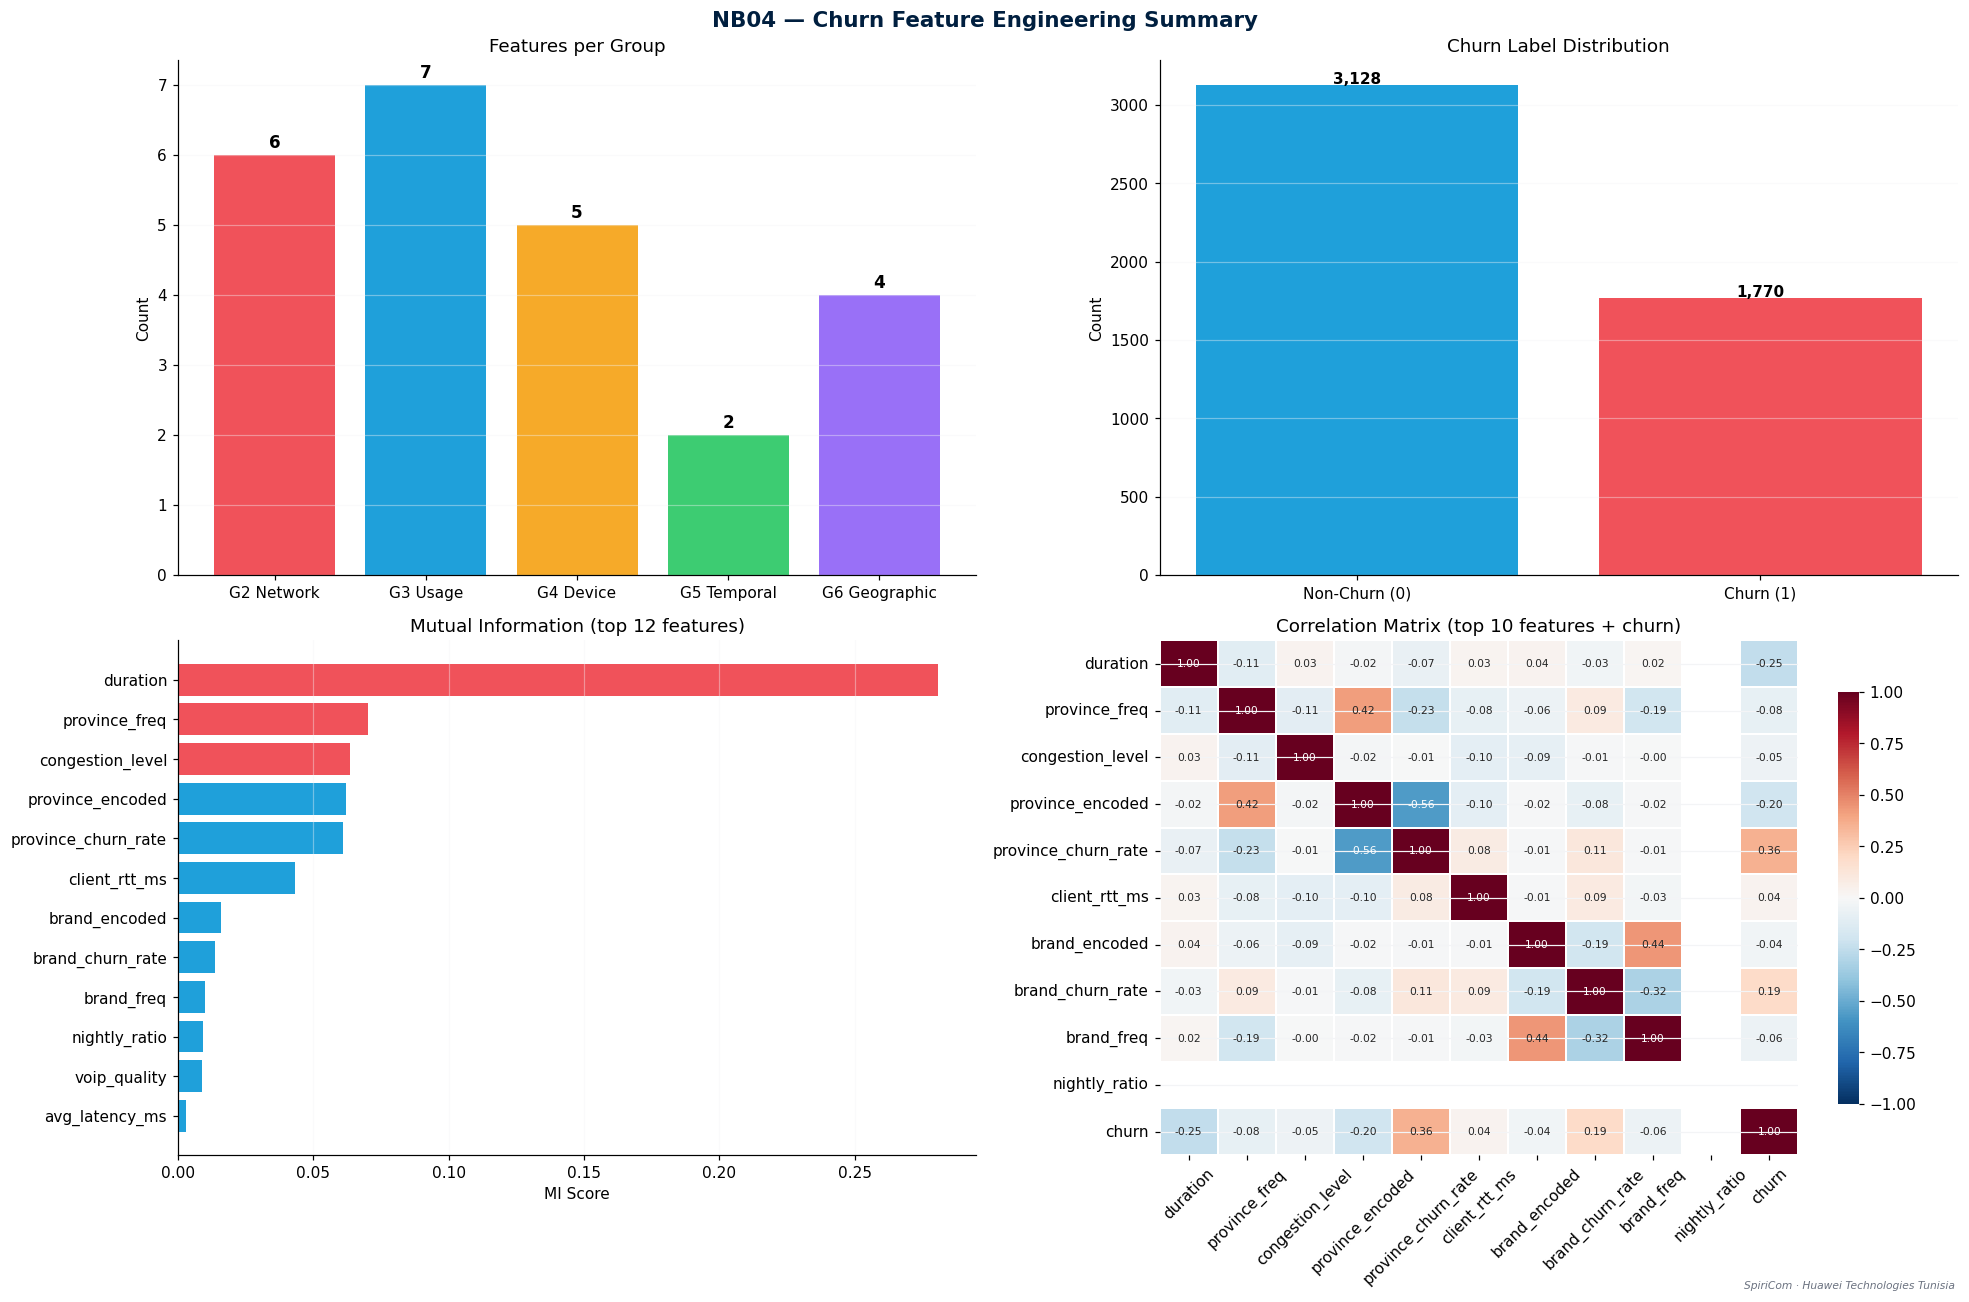

In [9]:
# ── §4  Visualisations ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('NB04 — Churn Feature Engineering Summary',
             fontsize=14, fontweight='bold', color=HW['navy'])

# A: Feature group sizes
ax = axes[0, 0]
groups = {'G2 Network':len(G2),'G3 Usage':len(G3),'G4 Device':len(G4),
          'G5 Temporal':len(G5),'G6 Geographic':len(G6)}
colors = [HW['red'],HW['blue'],HW['amber'],HW['green'],HW['purple']]
ax.bar(groups.keys(), groups.values(), color=colors, alpha=0.88)
for i, (k, v) in enumerate(groups.items()):
    ax.text(i, v+0.1, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Features per Group')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.4); ax.grid(axis='x', visible=False)

# B: Churn distribution
ax = axes[0, 1]
vals = feat['churn'].value_counts()
ax.bar(['Non-Churn (0)','Churn (1)'], [vals.get(0,0), vals.get(1,0)],
       color=[HW['blue'], HW['red']], alpha=0.88)
for i, v in enumerate([vals.get(0,0), vals.get(1,0)]):
    ax.text(i, v+10, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Churn Label Distribution')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.4); ax.grid(axis='x', visible=False)

# C: MI scores
ax = axes[1, 0]
if 'mi_series' in dir() and len(mi_series):
    top = mi_series.head(12)
    bar_colors = [HW['red'] if i < 3 else HW['blue'] for i in range(len(top))]
    ax.barh(top.index[::-1], top.values[::-1], color=bar_colors[::-1], alpha=0.88)
    ax.set_title('Mutual Information (top 12 features)')
    ax.set_xlabel('MI Score')
    ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)
else:
    ax.text(0.5, 0.5, 'Run validation cell first', ha='center', va='center',
            transform=ax.transAxes, color=HW['muted'])

# D: Correlation heatmap (top 10 features)
ax = axes[1, 1]
top10 = mi_series.head(10).index.tolist() if 'mi_series' in dir() else ALL_FEAT[:10]
corr = feat[top10 + ['churn']].corr()
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix (top 10 features + churn)')
ax.tick_params(axis='x', rotation=45)

wm(fig); plt.tight_layout()
save_fig('fig04_A_feature_summary')
plt.show()

In [10]:
# ── §5  Save artifacts ────────────────────────────────────────────────
# ── 5.1  churn_features.parquet ──────────────────────────────────────
# Include msisdn + churn + all 24 features
SAVE_COLS = ['msisdn', 'churn'] + [c for c in ALL_FEAT if c in feat.columns]
feat_out  = feat[SAVE_COLS].copy()

# Save to both standard paths
for out_path in [
    PROC_DIR / 'churn_features.parquet',
    OUT_DIR  / 'churn_features.parquet',
]:
    feat_out.to_parquet(out_path, index=False)
    print(f'✅ {out_path}')

# ── 5.2  Feature catalog JSON ─────────────────────────────────────────
catalog = {
    'n_features':    len(ALL_FEAT),
    'n_rows':        len(feat_out),
    'feature_cols':  ALL_FEAT,
    'groups': {
        'G2_network':    G2,
        'G3_usage':      G3,
        'G4_device':     G4,
        'G5_temporal':   G5,
        'G6_geographic': G6,
    },
    'leakage_excluded': list(LEAKAGE),
    'churn_rate':    round(float(feat_out['churn'].mean()), 4),
    'null_count':    int(feat_out[ALL_FEAT].isnull().sum().sum()),
}
catalog_path = OUT_DIR / 'feature_catalog.json'
with open(catalog_path, 'w', encoding='utf-8') as f:
    json.dump(catalog, f, indent=2)
print(f'✅ {catalog_path}')

# ── 5.3  Imputer (median fill) ────────────────────────────────────────
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
imputer.fit(feat_out[ALL_FEAT])
joblib.dump(imputer, MODEL_DIR / 'imputer.pkl')
print(f'✅ models/imputer.pkl')

# ── 5.4  Summary ─────────────────────────────────────────────────────
figs = sorted(FIG_DIR.glob('fig04_*.png'))
print()
print('=' * 60)
print('NOTEBOOK 04 — CHURN FEATURE ENGINEERING COMPLETE')
print('=' * 60)
print(f'  Rows in feature matrix : {len(feat_out):,}')
print(f'  Total features         : {len(ALL_FEAT)}')
print(f'  Feature groups:')
for gname, gcols in [('G2 Network',G2),('G3 Usage',G3),('G4 Device',G4),
                      ('G5 Temporal',G5),('G6 Geographic',G6)]:
    present_g = [c for c in gcols if c in feat_out.columns]
    print(f'    {gname:<20s}: {len(present_g)} features  {present_g}')
mi_top3 = mi_series.head(3).index.tolist() if 'mi_series' in dir() else ['N/A']
print(f'  Top 3 features (MI)    : {mi_top3}')
print(f'  Imbalance ratio        : 1:{ratio}')
print(f'  Null count             : {feat_out[ALL_FEAT].isnull().sum().sum()}')
print(f'  Artifacts saved:')
print(f'    data/processed/churn_features.parquet')
print(f'    data/outputs/churn_features.parquet')
print(f'    data/outputs/feature_catalog.json')
print(f'    models/imputer.pkl')
print(f'    models/le_brand.pkl')
print(f'    models/le_province.pkl')
print(f'  Figures: {len(figs)}')
print()
print('Next → Run 05_Churn_Modeling.ipynb')

✅ data\processed\churn_features.parquet
✅ data\outputs\churn_features.parquet
✅ data\outputs\feature_catalog.json
✅ models/imputer.pkl

NOTEBOOK 04 — CHURN FEATURE ENGINEERING COMPLETE
  Rows in feature matrix : 4,898
  Total features         : 24
  Feature groups:
    G2 Network          : 6 features  ['avg_packet_loss', 'avg_latency_ms', 'client_rtt_ms', 'voip_quality', 'session_active_rate', 'ratio_5g']
    G3 Usage            : 7 features  ['total_traffic', 'traffic_5g', 'duration', 'nightly_ratio', 'gaming_ratio', 'social_ratio', 'traffic_diversity']
    G4 Device           : 5 features  ['brand_encoded', 'brand_freq', 'brand_churn_rate', 'generation_numeric', 'is_5g_capable']
    G5 Temporal         : 2 features  ['days_since_last_activity', 'activity_recency_score']
    G6 Geographic       : 4 features  ['province_encoded', 'province_freq', 'province_churn_rate', 'congestion_level']
  Top 3 features (MI)    : ['duration', 'province_freq', 'congestion_level']
  Imbalance ratio   

---
## Design notes

### Why this notebook is robust

Every feature group uses the same pattern:
1. **Check if the column already exists** in the source KPI data → use directly
2. **Check for alternate names** (social_media_ratio → social_ratio)
3. **Derive from related features** if absent (congestion_level from packet_loss + latency)
4. **Fill with 0** as last resort with a clear warning

This means **Kernel → Restart & Run All** always produces a complete 24-feature matrix
without manual intervention between cells.

### Feature groups

| Group | Features | Source |
|-------|----------|--------|
| G2 Network | 6 | kpi_clean: latency, packet loss, RTT, VoIP, session rate, 5G ratio |
| G3 Usage | 7 | kpi_clean: traffic volumes, duration, usage ratios |
| G4 Device | 5 | brand encoding + churn rate + generation + 5G capability |
| G5 Temporal | 2 | Days since active + recency score (derived if absent) |
| G6 Geographic | 4 | Province encoding + frequency + churn rate + congestion |

---
*SpiriCom · NOC Intelligence Platform · Huawei Technologies Tunisia · PFE 2026*